In [ ]:
!pip install bs4
!pip install requests pandas

In [ ]:
from bs4 import BeautifulSoup
import requests
import pandas as pd

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
url = 'http://www.ibm.com'

In [ ]:
r = requests.get(url)

In [ ]:
html = r.text

In [ ]:
soup = BeautifulSoup(html, 'html.parser')

In [ ]:
# Scraping links
links = soup.find_all('a', href = True)
for link in links:
    print(link.get('href'))

https://www.ibm.com/events/think?lnk=hpthls1us
https://www.ibm.com/think/videos/think-keynotes?lnk=hpthls2us
https://newsroom.ibm.com/2026-05-05-think-2026-ibm-delivers-the-blueprint-for-the-ai-operating-model-as-the-ai-divide-widens?lnk=hpthrc1us
https://www.ibm.com/thought-leadership/institute-business-value/c-suite-study/ceo?lnk=hpthrc2us
https://www.ibm.com/forms/mkt-53811?lnk=hpthrc3us
https://bob.ibm.com/trial?lnk=hpthrc4us
http://www.ibm.com/new/announcements/shifting-from-ai-assisted-coding-to-ai-assisted-delivery-with-ibm-bob?lnk=hpthanus
https://www.ibm.com/new/announcements/from-insight-to-action-closing-the-gap-in-modern-it-operations?lnk=hpthanus
https://www.ibm.com/new/announcements/ibm-data-gate-for-confluent-turning-z-data-into-real-time-action?lnk=hpthanus
https://www.ibm.com/new/announcements/ibm-sovereign-core-the-new-end-to-end-system-for-sovereign-ai?lnk=hpthanus
https://www.ibm.com/case-studies/ibm-client-zero?lnk=hpcs1us
https://www.ibm.com/case-studies/blue-pear

In [ ]:
# Scraping Image Tags
image_tags = soup.find_all('img')
for link in image_tags:
    print(link.get('src'))

https://assets.ibm.com/is/image/ibm/think-2026_568x568?ts=1778094812299&dpr=off
https://assets.ibm.com/is/image/ibm/1616-2026-ceo-study-data_568x320?ts=1778009908664&dpr=off
https://assets.ibm.com/is/image/ibm/cloud_iso_automation_1x1b?ts=1778094824735&dpr=off
https://assets.ibm.com/is/image/ibm/ibm-bob-head-1x1?ts=1777637506575&dpr=off
https://assets.ibm.com/is/image/ibm/ibm_think_layersb_editorial_still_4k?ts=1778094829333&dpr=off
https://assets.ibm.com/is/image/ibm/bob-imagery-3200x1280?ts=1778094826638&dpr=off
https://assets.ibm.com/is/image/ibm/ibm-logo-2x1?ts=1778094832785&dpr=off
https://assets.ibm.com/is/image/ibm/blue-pearl-logo-2x1-v2-1?ts=1778094835409&dpr=off
https://assets.ibm.com/is/image/ibm/ferrari-shield-transparent?ts=1778094838131&dpr=off
https://assets.ibm.com/is/image/ibm/pfizer_logo-1?ts=1778094840956&dpr=off
https://assets.ibm.com/is/image/ibm/ibm2569_client_zero_procurement?ts=1778094832442&dpr=off
https://assets.ibm.com/is/image/ibm/adobestock_1082894866?ts=177

In [ ]:
import requests
from bs4 import BeautifulSoup

# Scrape html table from wikipedia and turn it into a pandas dataframe
new_url = 'https://en.wikipedia.org/wiki/List_of_countries_by_population_(United_Nations)'

# Add a User-Agent header to the request to avoid being blocked by Wikipedia
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}
r = requests.get(new_url, headers=headers)
html = r.text
soup = BeautifulSoup(html, 'html.parser')

In [ ]:
tables = soup.find_all('table')

In [ ]:
# Get the page title
page_title = soup.title.string
print(f"Page Title: {page_title}")

Page Title: List of countries and dependencies by population (United Nations) - Wikipedia


In [ ]:
# Find the first paragraph (p tag) and print its text
print("First Paragraph Text:")
first_paragraph = soup.find('p')
if first_paragraph:
    print(first_paragraph.text)

First Paragraph Text:
This is the list of countries and other inhabited territories of the world by estimated total population. It is based on estimates published by the United Nations in the 2024 revision of World Population Prospects. It presents population estimates from 1950 to the present.[2]



In [ ]:

# Convert tables to pandas dataframe
df = pd.read_html(str(tables[0]))[0]

# Clean and convert 'Change (%)' column to numeric
df['Change (%)'] = df['Change (%)'].str.replace('%', '', regex=False)
df['Change (%)'] = df['Change (%)'].str.replace('+', '', regex=False)
# Replace Unicode minus sign (U+2212) with a standard hyphen-minus
df['Change (%)'] = df['Change (%)'].str.replace('−', '-', regex=False)
df['Change (%)'] = pd.to_numeric(df['Change (%)'])

df.head()

/tmp/ipykernel_13913/4210266651.py:2: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(str(tables[0]))[0]


,Country or territory,Population (1 July 2022),Population (1 July 2023),Change (%),UN continental region[1],UN statistical subregion[1]
0,World,8021407192,8091734930,0.88,–,–
1,India,1425423212,1438069596,0.89,Asia,Southern Asia
2,China[a],1425179569,1422584933,-0.18,Asia,Eastern Asia
3,United States,341534046,343477335,0.57,Americas,Northern America
4,Indonesia,278830529,281190067,0.85,Asia,South-eastern Asia


### Population Growth in SEA Countries

/tmp/ipykernel_13913/179436475.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = 'Country or territory', y = 'Change (%)', data = df_sea, palette= 'mako')


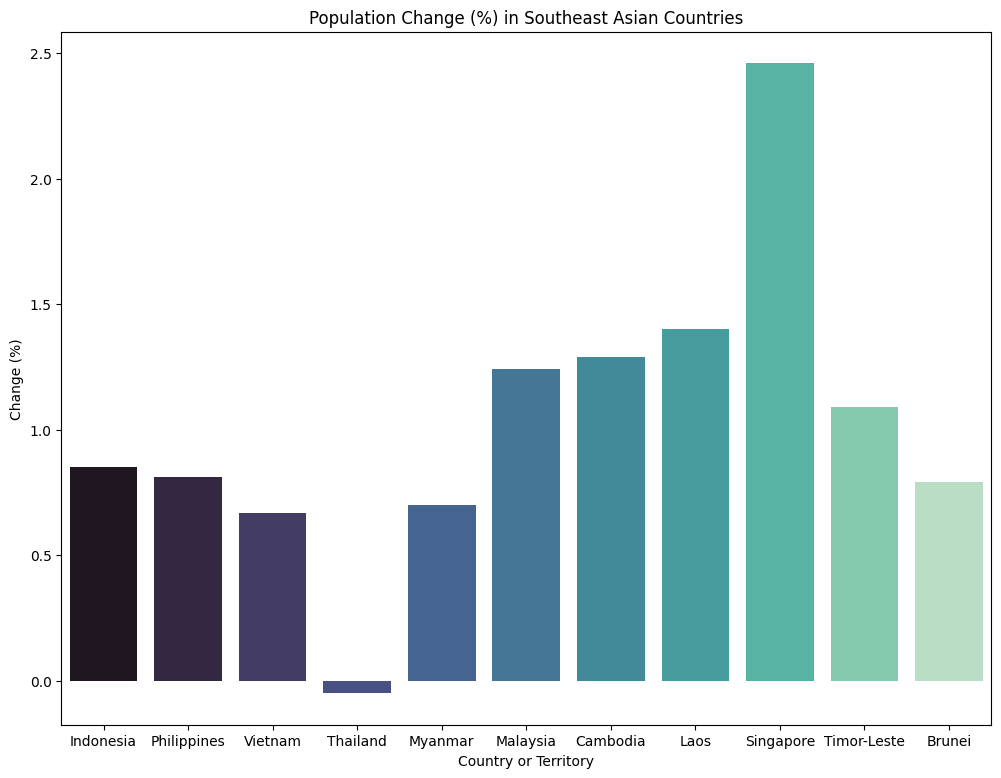

In [ ]:
df_sea = df[df['UN statistical subregion[1]'] == 'South-eastern Asia']
plt.figure(figsize=(12, 9))
sns.barplot(x = 'Country or territory', y = 'Change (%)', data = df_sea, palette= 'mako')
plt.title('Population Change (%) in Southeast Asian Countries')
plt.xlabel('Country or Territory')
plt.ylabel('Change (%)')
plt.show()

### Calculate the mean 'Change (%)' for each continent

In [ ]:

continent_mean_change = df.groupby('UN continental region[1]')['Change (%)'].mean().reset_index()
continent_mean_change

,UN continental region[1],Change (%)
0,Africa,2.131724
1,Americas,0.494000
2,Asia,1.423725
3,Europe,0.212400
4,Oceania,0.221739
5,–,0.880000


/tmp/ipykernel_13913/2854000083.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='UN continental region[1]', y='Change (%)', data=continent_mean_change, palette='coolwarm')


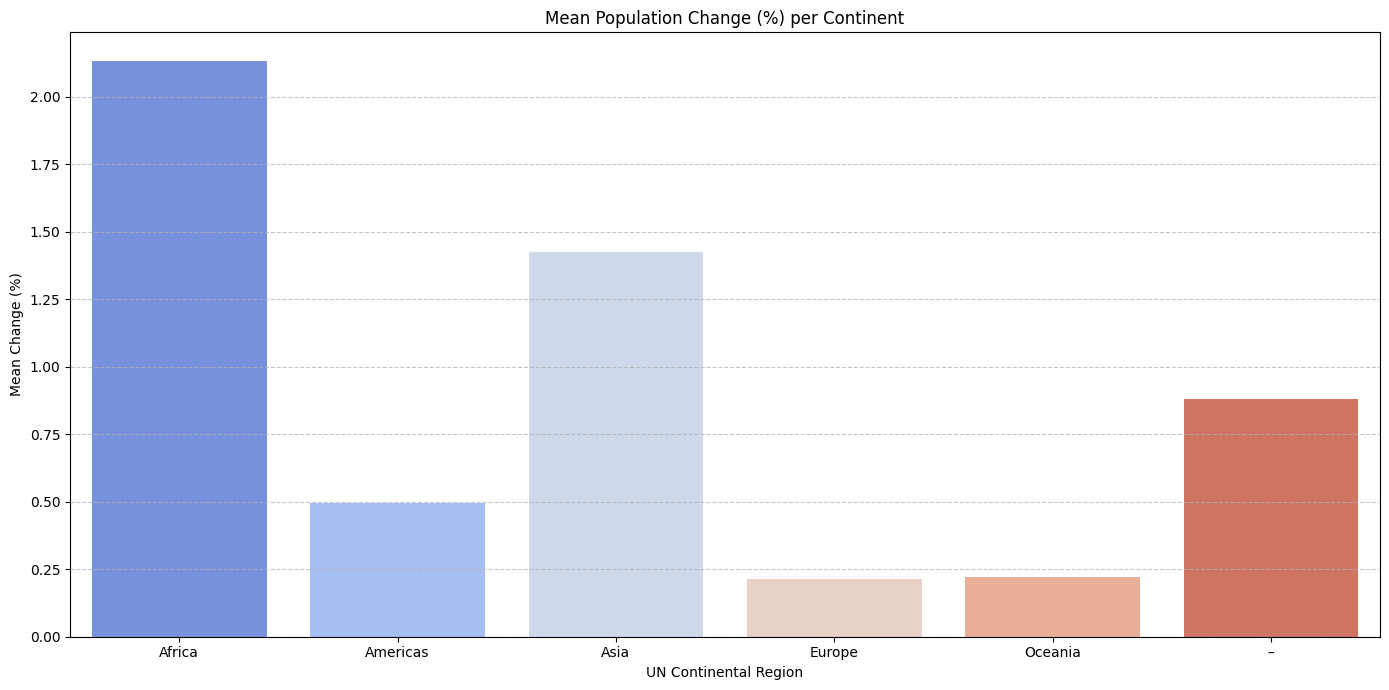

In [ ]:
plt.figure(figsize=(14, 7))
sns.barplot(x='UN continental region[1]', y='Change (%)', data=continent_mean_change, palette='coolwarm')
plt.title('Mean Population Change (%) per Continent')
plt.xlabel('UN Continental Region')
plt.ylabel('Mean Change (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(14, 7))
sns.barplot(y='UN continental region[1]', x='Change (%)', data=continent_mean_change, palette='coolwarm')
plt.title('Mean Population Change (%) per Continent (Horizontal Bar Chart)')
plt.xlabel('Mean Change (%)')
plt.ylabel('UN Continental Region')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Population Growth/Decline (2022 vs 2023)

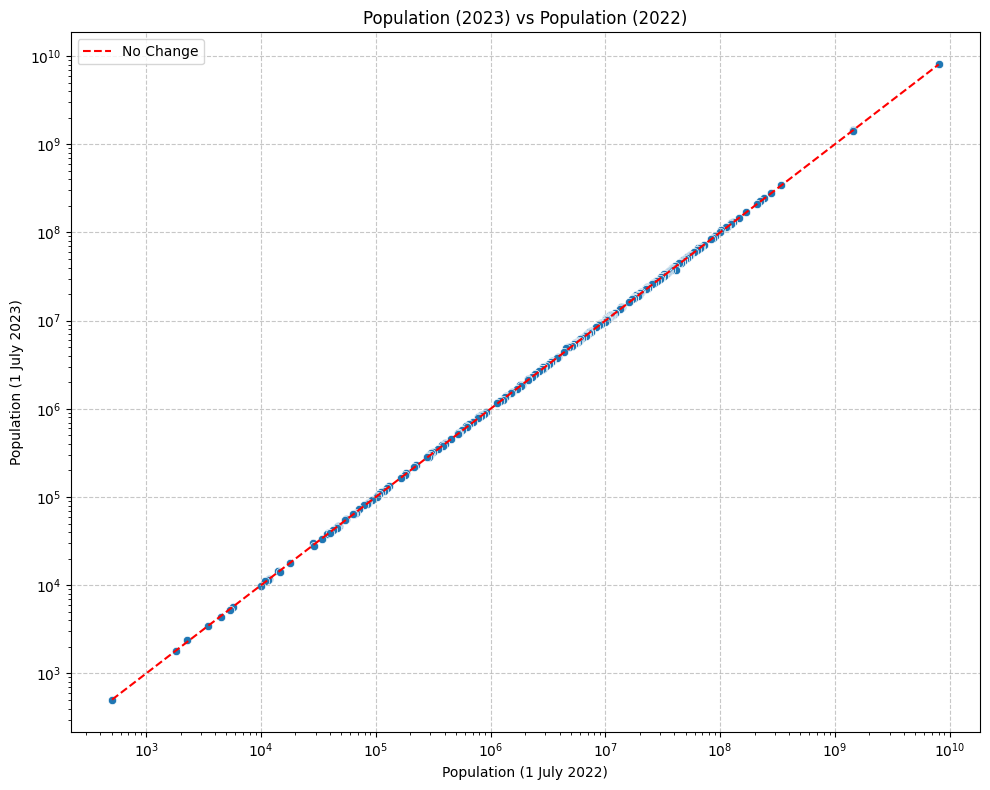

In [56]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Population (1 July 2022)', y='Population (1 July 2023)', data=df)
plt.title('Population (2023) vs Population (2022)')
plt.xlabel('Population (1 July 2022)')
plt.ylabel('Population (1 July 2023)')
plt.plot([df['Population (1 July 2022)'].min(), df['Population (1 July 2022)'].max()],
         [df['Population (1 July 2022)'].min(), df['Population (1 July 2022)'].max()],
         color='red', linestyle='--', label='No Change')
plt.xscale('log') # Use log scale for better visualization due to large range
plt.yscale('log') # Use log scale for better visualization due to large range
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

### Distribution of Population Change (%)

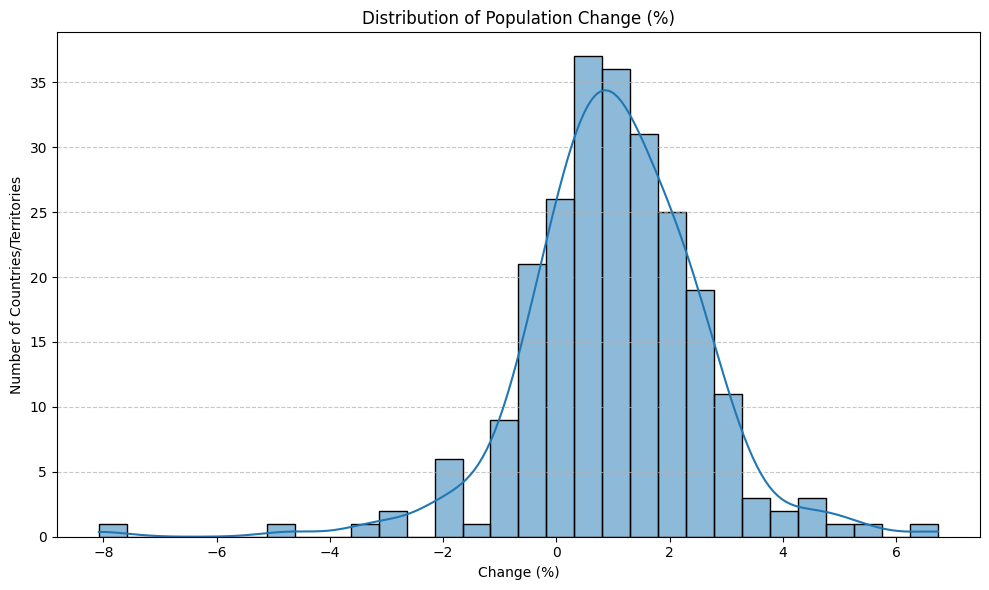

In [50]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Change (%)'], kde=True, bins=30)
plt.title('Distribution of Population Change (%)')
plt.xlabel('Change (%)')
plt.ylabel('Number of Countries/Territories')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Top 10 Countries/Territories by Population (1 July 2023)

/tmp/ipykernel_13913/2177726273.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Population (1 July 2023)', y='Country or territory', data=top_10_population, palette='viridis')


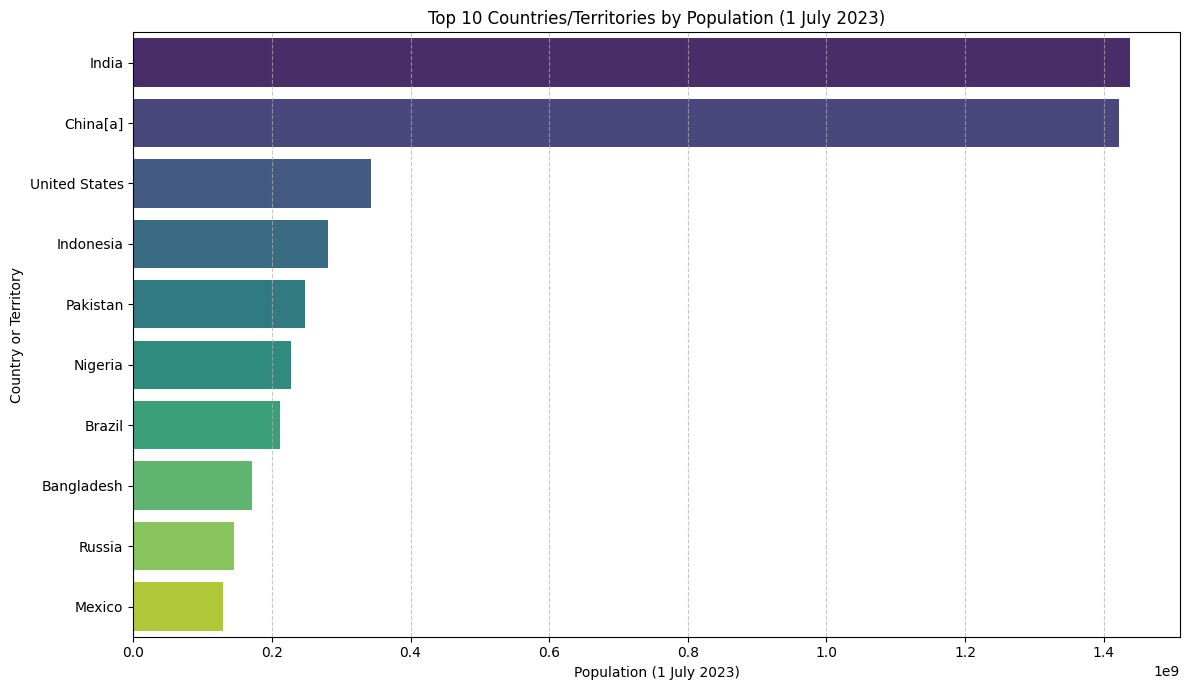

In [53]:
df_filtered = df[df['Country or territory'] != 'World']
top_10_population = df_filtered.nlargest(10, 'Population (1 July 2023)')

plt.figure(figsize=(12, 7))
sns.barplot(x='Population (1 July 2023)', y='Country or territory', data=top_10_population, palette='viridis')
plt.title('Top 10 Countries/Territories by Population (1 July 2023)')
plt.xlabel('Population (1 July 2023)')
plt.ylabel('Country or Territory')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()